# explore color cuts for target selection

In [1]:
import numpy as np 
from astropy.table import Table
import corner as DFM

In [2]:
# --- plotting ---
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

# load Kota's VI catalog and LAM 1D reduction for Run 21

In [9]:
kota = Table.read('/Users/hahnchanghoon/data/pfs/kota_vi_run21_extra.fits')
print(len(kota))

# redshift quality cuts based on VI
pass_vi3 = 0.5*(kota['user1'] + kota['user2']) >= 3
pass_vi4 = 0.5*(kota['user1'] + kota['user2']) >= 4

7449


In [10]:
# LAM 1D reduction for S25a sent by Jingjing
lam1d = Table.read('/Users/hahnchanghoon/data/pfs/lam1d_s25a_matched.fits')
print(len(lam1d))

# internal LAM 1D redshift quality cut
# only with good LAM 1D redshifts
best_lam = ((lam1d['probaGalaxy'] > 0.99) & 
           (lam1d['redshiftProba'] > 0.99) & 
           (lam1d['redshiftError'] < 0.01))
print('LAM-BEST %.3f' % np.mean(best_lam))

61684
LAM-BEST 0.637


In [11]:
# compile HSC photometry
# extinction corrected magnitudes 
g_mag = lam1d['g_cmodel_mag'] - lam1d['a_g']
r_mag = lam1d['r_cmodel_mag'] - lam1d['a_r']
i_mag = lam1d['i_cmodel_mag'] - lam1d['a_i']
z_mag = lam1d['z_cmodel_mag'] - lam1d['a_z']

match the catalogs

In [13]:
# match to Kota
i_match_kota = []
for objid in kota['objId']: 
    _match = (objid == lam1d_s25a['obj_id'])
    assert np.sum(_match) == 1

    i_match_kota.append(np.arange(len(lam1d_s25a))[_match])

i_match_kota = np.array(i_match_kota).flatten()

# redshift success rates

In [12]:
# sample the colormaps that you want to use. Use 128 from each so we get 256
# colors in total
clrs1 = plt.cm.Blues(np.linspace(0.5, 1, 20))
clrs2 = plt.cm.Spectral_r(np.linspace(0.2, 1, 80))

# combine them and build a new colormap
colors = np.vstack((clrs2, clrs1))
mymap = mpl.colors.LinearSegmentedColormap.from_list('my_colormap', colors)

Text(0, 0.5, 'quality cut')

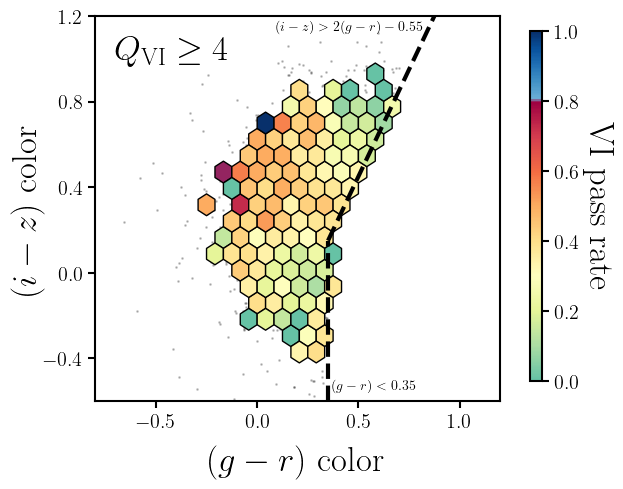

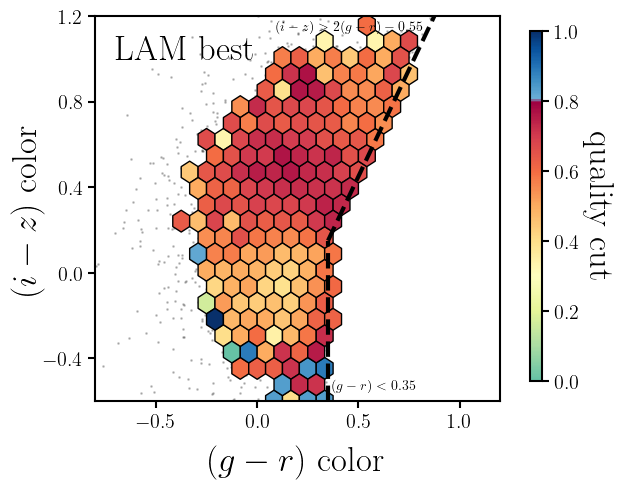

In [16]:
fig = plt.figure(figsize=(6,5))
sub = fig.add_subplot(111)
sub.scatter(
    (g_mag - r_mag)[i_match_kota], # (g-r)
    (i_mag - z_mag)[i_match_kota], # (i-z)
    c='k', s=1, alpha=0.2)
hb = sub.hexbin(
    (g_mag - r_mag)[i_match_kota], # (g-r)
    (i_mag - z_mag)[i_match_kota], # (i-z)
    C=pass_vi4.astype(float), 
    edgecolors='k', linewidth=1., reduce_C_function=np.mean, 
    extent=(-1, 1.5, -0.6, 2), gridsize=30, vmin=0., vmax=1., mincnt=5, cmap=mymap)#'Spectral_r')

sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)

sub.text(0.05, 0.95, r'$Q_{\rm VI} \ge 4$', ha='left', va='top', transform=sub.transAxes, fontsize=25)

sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)
sub.set_xlim(-0.8, 1.2)
sub.set_ylim(-0.6, 1.2)
sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])

bkgd = fig.add_subplot(111, frameon=False)
bkgd.set_xlabel(r'$(g - r)$ color', labelpad=10, fontsize=25) 
bkgd.set_ylabel(r'$(i - z)$ color', labelpad=10, fontsize=25) 
bkgd.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
fig.subplots_adjust(wspace=0.1, right=0.8)

cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'VI pass rate', labelpad=25, fontsize=25, rotation=270)


fig = plt.figure(figsize=(6,5))
sub = fig.add_subplot(111)

sub.scatter(
    (g_mag - r_mag), # (g-r)
    (i_mag - z_mag), # (i-z)
    c='k', s=1, alpha=0.2)
hb = sub.hexbin(
    (g_mag - r_mag), # (g-r)
    (i_mag - z_mag), # (i-z)
    C=best_lam.astype(float), 
    edgecolors='k', linewidth=1., reduce_C_function=np.mean, 
    extent=(-1, 1.5, -0.6, 2), gridsize=30, vmin=0., vmax=1., mincnt=5, cmap=mymap)#'Spectral_r')

sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)

sub.text(0.05, 0.95, r'LAM best', ha='left', va='top', transform=sub.transAxes, fontsize=25)

sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)
sub.set_xlim(-0.8, 1.2)
sub.set_ylim(-0.6, 1.2)
sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])

bkgd = fig.add_subplot(111, frameon=False)
bkgd.set_xlabel(r'$(g - r)$ color', labelpad=10, fontsize=25) 
bkgd.set_ylabel(r'$(i - z)$ color', labelpad=10, fontsize=25) 
bkgd.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
fig.subplots_adjust(wspace=0.1, right=0.8)

cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'quality cut', labelpad=25, fontsize=25, rotation=270)

# color-space distribution

Text(0, 0.5, 'LAM 1D $z$')

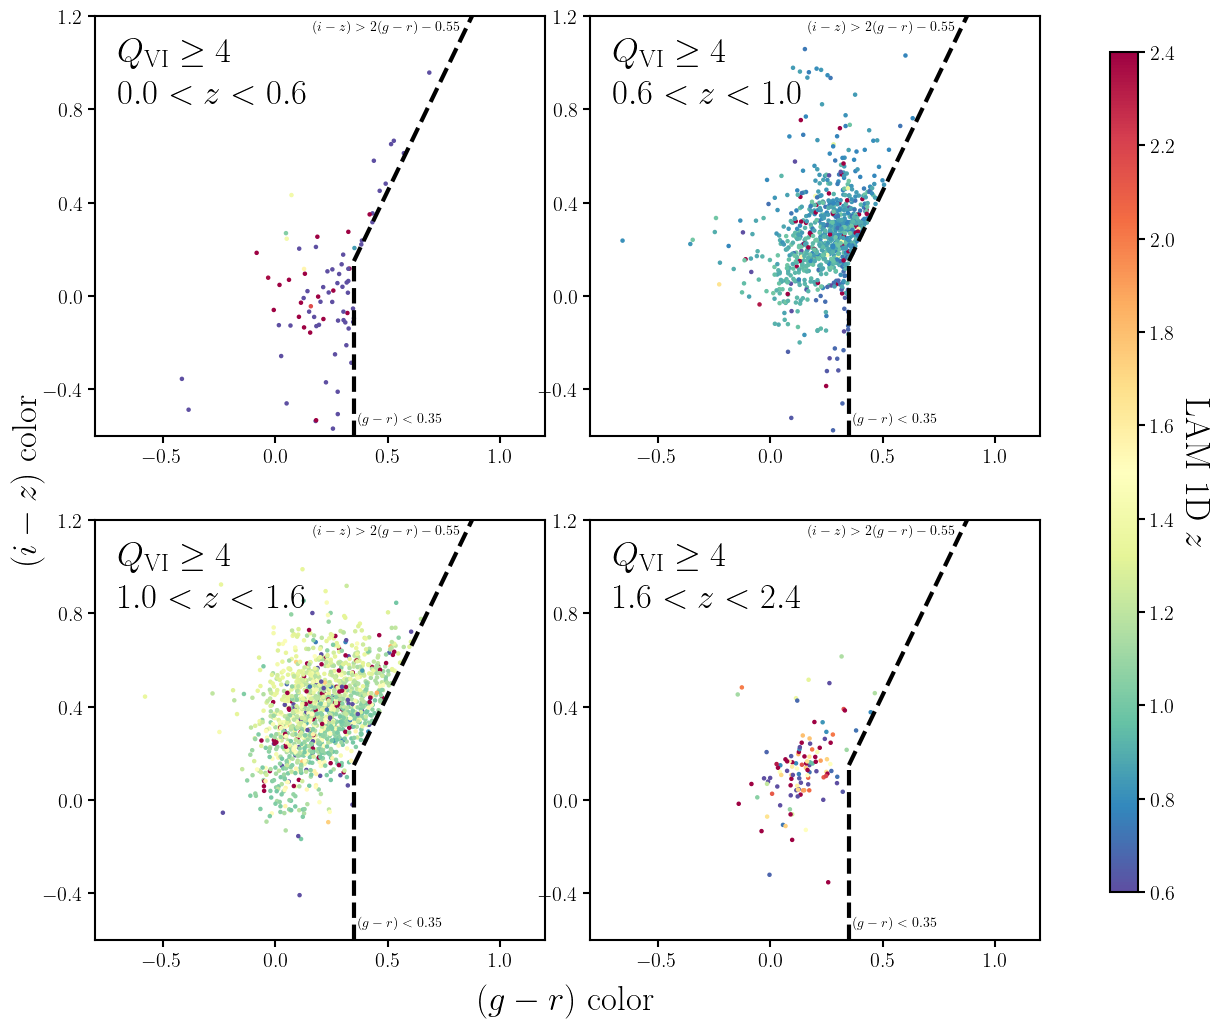

In [17]:
fig = plt.figure(figsize=(14, 12))
for i in range(4): 
    sub = fig.add_subplot(2,2,i+1)

    zlim = ((kota['z_measured'] > [0, 0.6, 1., 1.6][i]) & (kota['z_measured'] < [0.6, 1., 1.6, 2.4][i]) &
            (0.5*(kota['user1'] + kota['user2']) >= 4))
    hb = sub.scatter(
        (g_mag - r_mag)[i_match_kota][zlim], # (g-r)
        (i_mag - z_mag)[i_match_kota][zlim], # (i-z)
        c=lam1d_s25a[i_match_kota]['redshift'][zlim], s=5, vmin=0.6, vmax=2.4, cmap='Spectral_r')

    sub.text(0.05, 0.95, r'$Q_{\rm VI} \ge 4$', ha='left', va='top', transform=sub.transAxes, fontsize=25)
    sub.text(0.05, 0.85, r'$%.1f < z < %.1f$' % ([0, 0.6, 1., 1.6][i], [0.6, 1., 1.6, 2.4][i]), ha='left', va='top', transform=sub.transAxes, fontsize=25)
    
    sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
    sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)
    
    sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
    sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)
    sub.set_xlim(-0.8, 1.2)
    sub.set_ylim(-0.6, 1.2)
    sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])

bkgd = fig.add_subplot(111, frameon=False)
bkgd.set_xlabel(r'$(g - r)$ color', labelpad=10, fontsize=25) 
bkgd.set_ylabel(r'$(i - z)$ color', labelpad=10, fontsize=25) 
bkgd.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
fig.subplots_adjust(wspace=0.1, right=0.8)

cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'LAM 1D $z$', labelpad=25, fontsize=25, rotation=270)

0.0602263147655794
0.20966539134945852
0.29112897996238896
0.016406199338564294


Text(0, 0.5, '$z$')

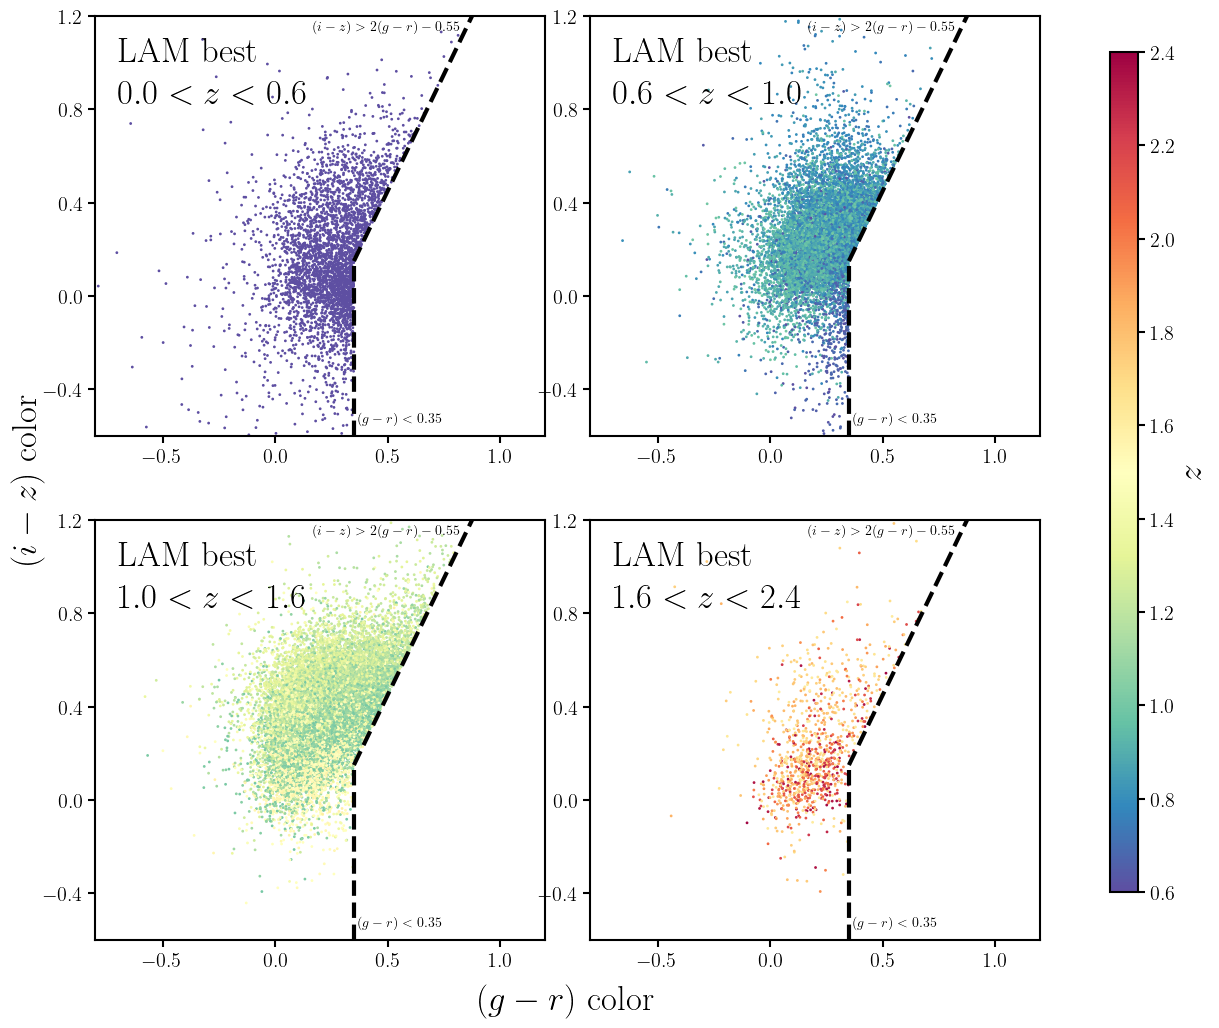

In [76]:
fig = plt.figure(figsize=(14, 12))
for i in range(4): 
    sub = fig.add_subplot(2,2,i+1)

    zlim = ((lam1d_s25a['redshift'] > [0, 0.6, 1., 1.6][i]) & (lam1d_s25a['redshift'] < [0.6, 1., 1.6, 2.4][i]) &
            best_lam)
    print(np.mean(zlim))
    hb = sub.scatter(
        (g_mag - r_mag)[zlim], # (g-r)
        (i_mag - z_mag)[zlim], # (i-z)
        c=lam1d_s25a['redshift'][zlim], s=1, vmin=0.6, vmax=2.4, cmap='Spectral_r')

    sub.text(0.05, 0.95, r'LAM best', ha='left', va='top', transform=sub.transAxes, fontsize=25)
    sub.text(0.05, 0.85, r'$%.1f < z < %.1f$' % ([0, 0.6, 1., 1.6][i], [0.6, 1., 1.6, 2.4][i]), ha='left', va='top', transform=sub.transAxes, fontsize=25)
    
    sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
    sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)
    
    sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
    sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)
    sub.set_xlim(-0.8, 1.2)
    sub.set_ylim(-0.6, 1.2)
    sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])

bkgd = fig.add_subplot(111, frameon=False)
bkgd.set_xlabel(r'$(g - r)$ color', labelpad=10, fontsize=25) 
bkgd.set_ylabel(r'$(i - z)$ color', labelpad=10, fontsize=25) 
bkgd.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
fig.subplots_adjust(wspace=0.1, right=0.8)

cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'$z$', labelpad=25, fontsize=25, rotation=270)

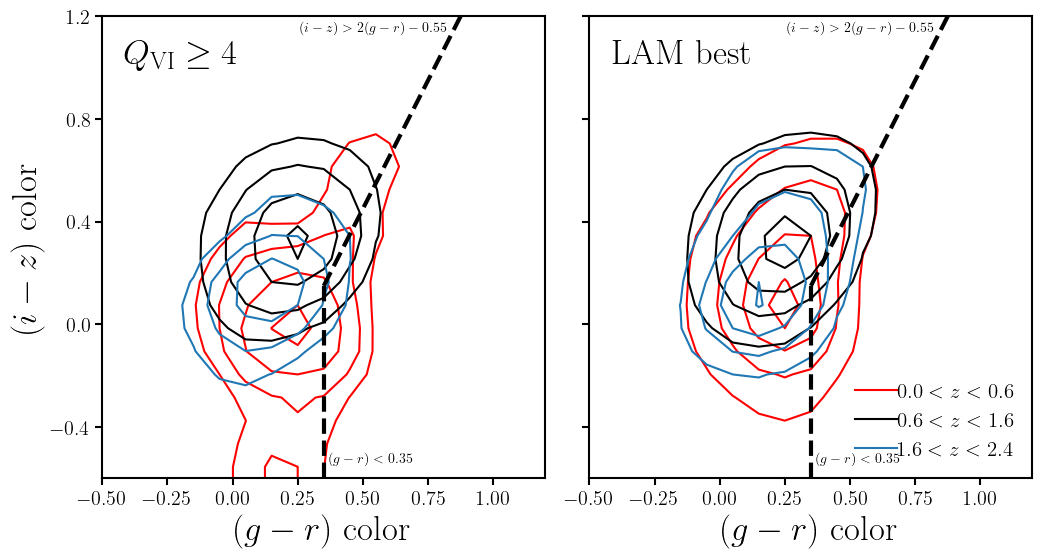

In [22]:
fig = plt.figure(figsize=(12,6))
sub = fig.add_subplot(121)
for i in range(3): 
    zlim = ((kota['z_measured'] > [0, 0.6, 1.6][i]) & (kota['z_measured'] < [0.6, 1.6, 2.4][i]) &
            (0.5*(kota['user1'] + kota['user2']) >= 4))
    _ = DFM.hist2d(
        (g_mag - r_mag)[i_match_kota][zlim], # (g-r)
        (i_mag - z_mag)[i_match_kota][zlim], # (i-z)
        color=['r', 'k', 'C0'][i],
        range=[(-0.8, 1.2), (-0.6, 1.2)], bins=20, 
        plot_density=False, plot_datapoints=False, smooth=True, ax=sub)
    sub.plot([], [], c=['r', 'k', 'C0'][i],
             label=r'$%.1f < z < %.1f$' % ([0, 0.6, 1.6][i], [0.6, 1.6, 2.4][i]))
        
sub.text(0.05, 0.95, r'$Q_{\rm VI} \ge 4$', ha='left', va='top', transform=sub.transAxes, fontsize=25)

sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)

sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)

sub.set_xlabel(r'$(g - r)$ color', fontsize=25) 
sub.set_xlim(-0.5, 1.2)
sub.set_ylabel(r'$(i - z)$ color', fontsize=25) 
sub.set_ylim(-0.6, 1.2)
sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])

sub = fig.add_subplot(122)
for i in range(3): 
    zlim = ((lam1d_s25a['redshift'] > [0, 0.6, 1.6][i]) & (lam1d_s25a['redshift'] < [0.6, 1.6, 2.4][i]) &
            best_lam)
    _ = DFM.hist2d(
        (g_mag - r_mag)[zlim], # (g-r)
        (i_mag - z_mag)[zlim], # (i-z)
        color=['r', 'k', 'C0'][i],
        range=[(-0.8, 1.2), (-0.6, 1.2)], bins=20, 
        plot_density=False, plot_datapoints=False, smooth=True, ax=sub)
    sub.plot([], [], c=['r', 'k', 'C0'][i],
             label=r'$%.1f < z < %.1f$' % ([0, 0.6, 1.6][i], [0.6, 1.6, 2.4][i]))
        
sub.text(0.05, 0.95, r'LAM best', ha='left', va='top', transform=sub.transAxes, fontsize=25)

sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)

sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)

sub.legend(loc='lower right', handletextpad=0, fontsize=15)
sub.set_xlabel(r'$(g - r)$ color', fontsize=25) 
sub.set_xlim(-0.5, 1.2)
sub.set_ylim(-0.6, 1.2)
sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])
sub.set_yticklabels([])
fig.subplots_adjust(wspace=0.1)

Text(0, 0.5, '$z < 0.6$ fraction')

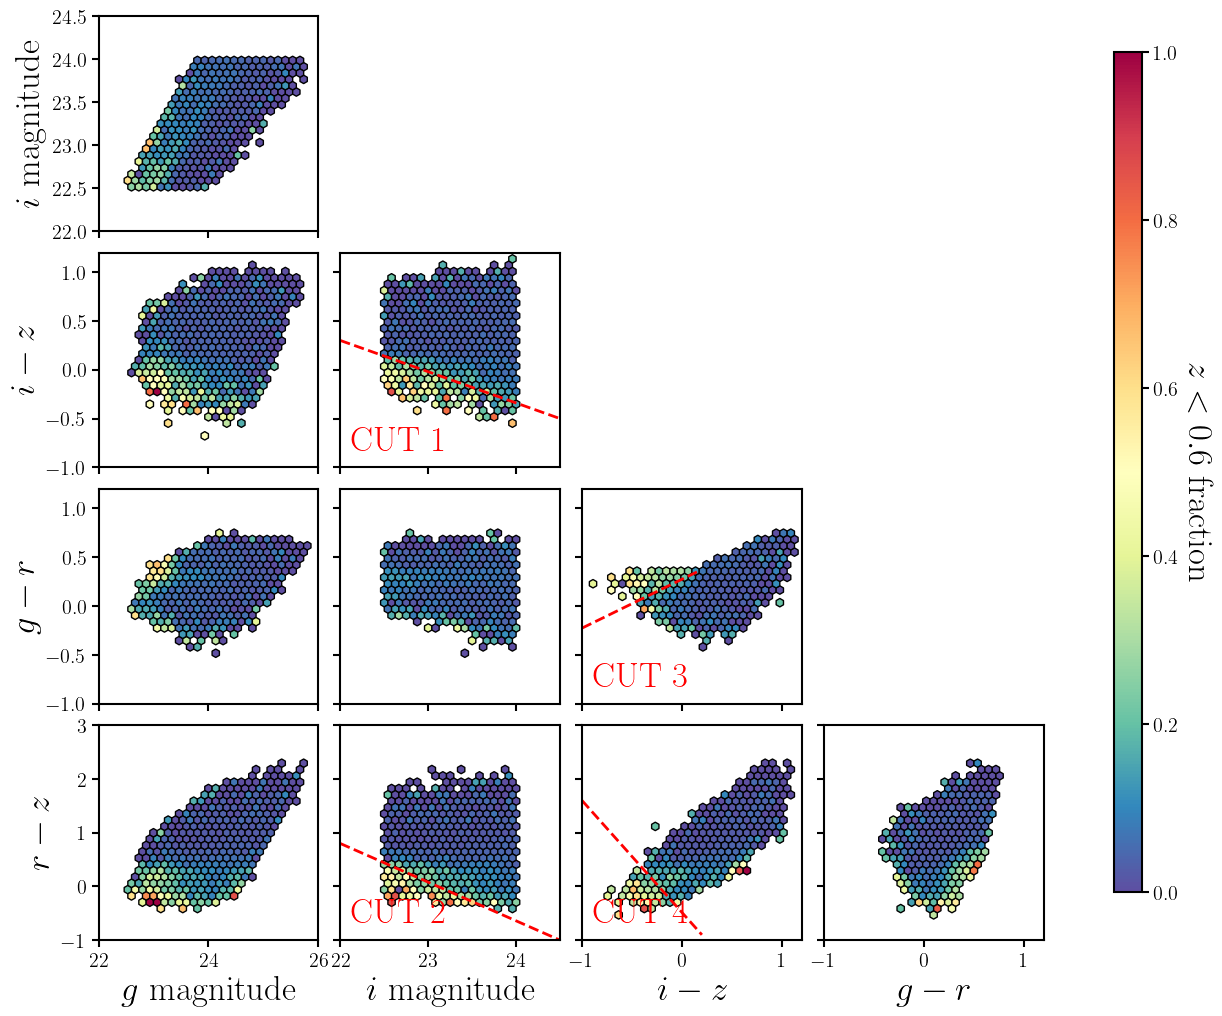

In [23]:
# Lets look at pairwise combo of g, i, (i-z), (g-r), (r-z) colors

_lbls = ['$g$ magnitude', '$i$ magnitude', '$i-z$', '$g-r$', '$r-z$']
_arrs = [g_mag, i_mag, i_mag - z_mag, g_mag - r_mag, r_mag - z_mag]
_ranges = [(22, 26), (22, 24.5), (-1., 1.2), (-1., 1.2), (-1., 3)] 

lowz_cut0 = (i_mag - z_mag) > 2 * (g_mag - r_mag) - 0.55 #$(i-z) > 2 (g-r) - 0.55


fig = plt.figure(figsize=(14, 12))
for i in range(5): 
    for j in range(5): 
        if j >= i: continue
        sub = fig.add_subplot(4,4,4*(i-1)+j+1)

        interpolers = (lam1d_s25a['redshift'] > 0) & (lam1d_s25a['redshift'] < 0.6) & best_lam # & lowz_cut0

        hb = sub.hexbin(
            _arrs[j],
            _arrs[i],
            C=interpolers.astype(int), 
            edgecolors='k', linewidth=1., reduce_C_function=np.mean, 
            extent=(_ranges[j][0], _ranges[j][1], 
                    _ranges[i][0], _ranges[i][1]), gridsize=30, vmin=0., vmax=1., mincnt=5, cmap='Spectral_r')
        sub.set_xlabel(_lbls[j], fontsize=25)
        sub.set_xlim(_ranges[j])
        sub.set_ylabel(_lbls[i], fontsize=25)
        sub.set_ylim(_ranges[i])
        
        if j == 1 and i == 2: 
            sub.plot([22., 24.5], [0.3, -0.5], c='r', lw=2, ls='--')
            sub.text(0.05, 0.05, r'CUT 1', color='r', ha='left', va='bottom', transform=sub.transAxes, fontsize=25)
        if j == 1 and i == 4: 
            sub.plot([22., 24.5], [0.8, -1], c='r', lw=2, ls='--')
            sub.text(0.05, 0.05, r'CUT 2', color='r', ha='left', va='bottom', transform=sub.transAxes, fontsize=25)
        if j == 2 and i == 3: 
            sub.plot([-1., 0.15], [-0.225, 0.35], c='r', lw=2, ls='--')
            sub.text(0.05, 0.05, r'CUT 3', color='r', ha='left', va='bottom', transform=sub.transAxes, fontsize=25)
        if j == 2 and i == 4: 
            sub.plot([-1., 0.2], [1.6, -0.9], c='r', lw=2, ls='--')
            sub.text(0.05, 0.05, r'CUT 4', color='r', ha='left', va='bottom', transform=sub.transAxes, fontsize=25)
            
        if j == 0 and i < 4: 
            sub.set_xticklabels([])
        
        if i < 4: 
            sub.set_xlabel('')
            sub.set_xticklabels([])
        if j > 0: 
            sub.set_yticklabels([])
            sub.set_ylabel('')
fig.subplots_adjust(wspace=0.1, hspace=0.1, right=0.8)

cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'$z < 0.6$ fraction', labelpad=25, fontsize=25, rotation=270)

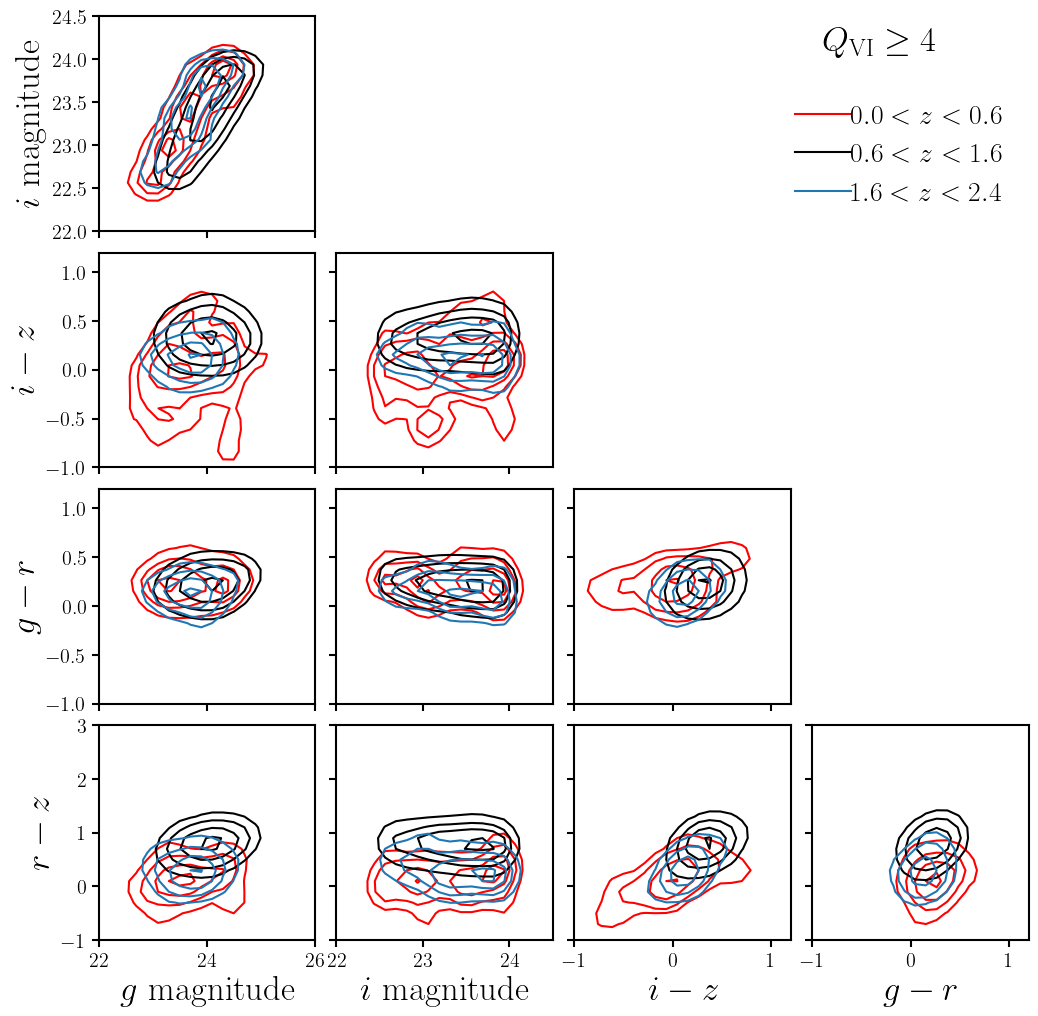

In [37]:
fig = plt.figure(figsize=(12, 12))
for i in range(5): 
    for j in range(5): 
        if j >= i: continue
        sub = fig.add_subplot(4,4,4*(i-1)+j+1)

        for _i in range(3): 
            _zlim = ((kota['z_measured'] > [0, 0.6, 1.6][_i]) & (kota['z_measured'] < [0.6, 1.6, 2.4][_i]) &
                    (0.5*(kota['user1'] + kota['user2']) >= 4))
            
            _ = DFM.hist2d(
                _arrs[j][i_match_kota][_zlim], 
                _arrs[i][i_match_kota][_zlim],
                color=['r', 'k', 'C0'][_i],
                range=[_ranges[j], _ranges[i]], bins=20, 
                plot_density=False, plot_datapoints=False, smooth=True, ax=sub)
        sub.set_xlabel(_lbls[j], fontsize=25)
        sub.set_xlim(_ranges[j])
        sub.set_ylabel(_lbls[i], fontsize=25)
        sub.set_ylim(_ranges[i])
        if j == 0 and i < 4: sub.set_xticklabels([])
        
        if i < 4: 
            sub.set_xlabel('')
            sub.set_xticklabels([])
        if j > 0: 
            sub.set_yticklabels([])
            sub.set_ylabel('')

sub = fig.add_subplot(4,4,4)
for _i in range(3): 
    sub.plot([], [], c=['r', 'k', 'C0'][_i],
                     label=r'$%.1f < z < %.1f$' % ([0, 0.6, 1.6][_i], [0.6, 1.6, 2.4][_i]))
sub.text(0.05, 0.95, r'$Q_{\rm VI} \ge 4$', ha='left', va='top', transform=sub.transAxes, fontsize=25)
sub.legend(loc='lower right', handletextpad=0., fontsize=20)
sub.axis('off')


fig.subplots_adjust(wspace=0.1, hspace=0.1)

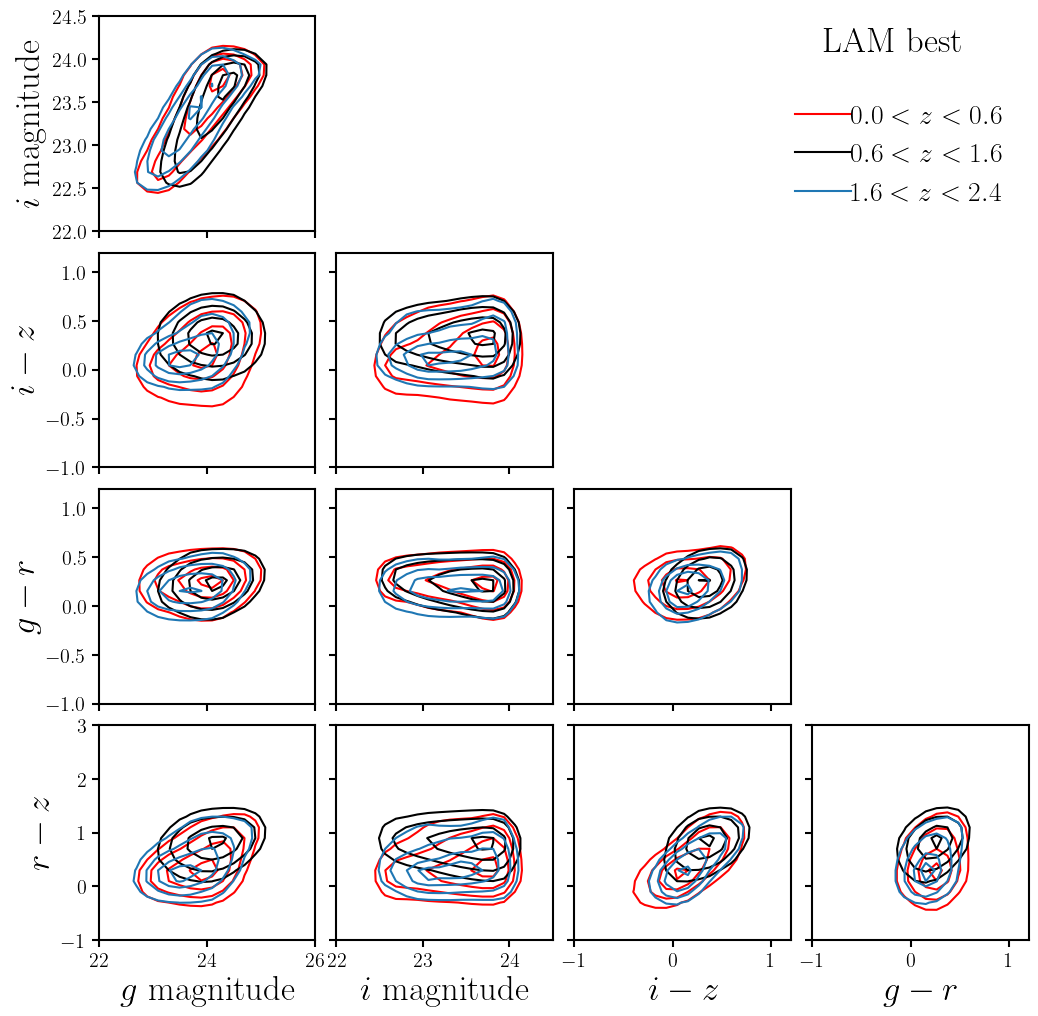

In [38]:
fig = plt.figure(figsize=(12, 12))
for i in range(5): 
    for j in range(5): 
        if j >= i: continue
        sub = fig.add_subplot(4,4,4*(i-1)+j+1)

        for _i in range(3): 
            _zlim = (lam1d_s25a['redshift'] > [0., 0.6, 1.6][_i]) & (lam1d_s25a['redshift'] < [0.6, 1.6, 2.4][_i]) & best_lam 
            _ = DFM.hist2d(
                _arrs[j][_zlim], 
                _arrs[i][_zlim],
                color=['r', 'k', 'C0'][_i],
                range=[_ranges[j], _ranges[i]], bins=20, 
                plot_density=False, plot_datapoints=False, smooth=True, ax=sub)
        sub.set_xlabel(_lbls[j], fontsize=25)
        sub.set_xlim(_ranges[j])
        sub.set_ylabel(_lbls[i], fontsize=25)
        sub.set_ylim(_ranges[i])
        
        if j == 0 and i < 4: sub.set_xticklabels([])
        
        if i < 4: 
            sub.set_xlabel('')
            sub.set_xticklabels([])
        if j > 0: 
            sub.set_yticklabels([])
            sub.set_ylabel('')

sub = fig.add_subplot(4,4,4)
for _i in range(3): 
    sub.plot([], [], c=['r', 'k', 'C0'][_i],
                     label=r'$%.1f < z < %.1f$' % ([0, 0.6, 1.6][_i], [0.6, 1.6, 2.4][_i]))
sub.text(0.05, 0.95, r'LAM best', ha='left', va='top', transform=sub.transAxes, fontsize=25)
sub.legend(loc='lower right', handletextpad=0., fontsize=20)
sub.axis('off')


fig.subplots_adjust(wspace=0.1, hspace=0.1)

# explore color-cuts to remove $z < 0.6$ contaminants 

In [27]:
cut0 = (i_mag - z_mag) > 2 * (g_mag - r_mag) - 0.55 #$(i-z) > 2 (g-r) - 0.55

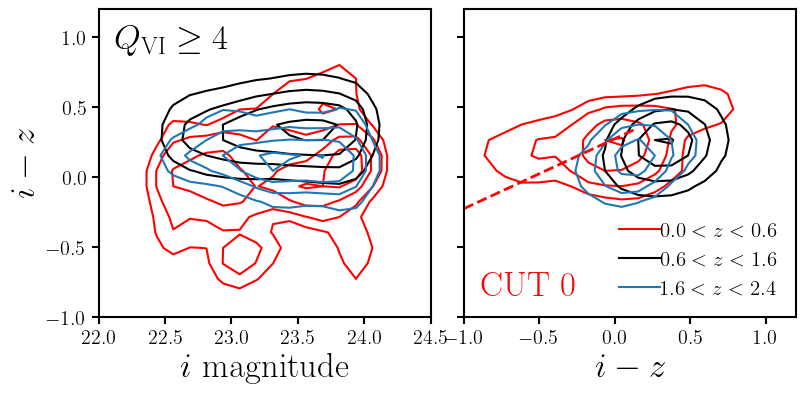

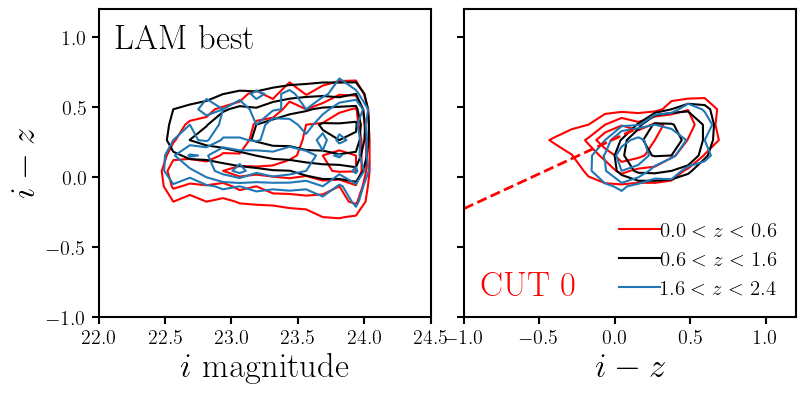

In [64]:
fig = plt.figure(figsize=(9, 4))
for _ii, i, j in zip([0, 1], [2, 3], [1, 2]): 
    sub = fig.add_subplot(1, 2, _ii+1)

    for _i in range(3): 
        _zlim = ((kota['z_measured'] > [0, 0.6, 1.6][_i]) & (kota['z_measured'] < [0.6, 1.6, 2.4][_i]) &
                    (0.5*(kota['user1'] + kota['user2']) >= 4))
            
        _ = DFM.hist2d(
            _arrs[j][i_match_kota][_zlim], 
            _arrs[i][i_match_kota][_zlim],
            color=['r', 'k', 'C0'][_i],
            range=[_ranges[j], _ranges[i]], bins=20, 
            plot_density=False, plot_datapoints=False, smooth=True, ax=sub)
    sub.set_xlabel(_lbls[j], fontsize=25)
    sub.set_xlim(_ranges[j])
    sub.set_ylabel(_lbls[i], fontsize=25)
    sub.set_ylim(_ranges[i])
    

    if j == 2 and i == 3: 
        sub.plot([-1., 0.15], [-0.225, 0.35], c='r', lw=2, ls='--')
        sub.text(0.05, 0.05, r'CUT 0', color='r', ha='left', va='bottom', transform=sub.transAxes, fontsize=25)
            
    if _ii > 0: 
        sub.set_yticklabels([])
        sub.set_ylabel('')
    else: 
        sub.text(0.05, 0.95, r'$Q_{\rm VI} \ge 4$', ha='left', va='top', transform=sub.transAxes, fontsize=25)
        
for _i in range(3): 
    sub.plot([], [], c=['r', 'k', 'C0'][_i],
                     label=r'$%.1f < z < %.1f$' % ([0, 0.6, 1.6][_i], [0.6, 1.6, 2.4][_i]))
sub.legend(loc='lower right', handletextpad=0., fontsize=15)

fig.subplots_adjust(wspace=0.1, hspace=0.1)
plt.show()

fig = plt.figure(figsize=(9, 4))
for _ii, i, j in zip([0, 1], [2, 3], [1, 2]): 
    sub = fig.add_subplot(1, 2, _ii+1)

    for _i in range(3): 
        _zlim = (lam1d_s25a['redshift'] > [0., 0.6, 1.6][_i]) & (lam1d_s25a['redshift'] < [0.6, 1.6, 2.4][_i]) & best_lam 
        _ = DFM.hist2d(
            _arrs[j][_zlim], 
            _arrs[i][_zlim],
            color=['r', 'k', 'C0'][_i],
            range=[_ranges[j], _ranges[i]], bins=20, 
            plot_density=False, plot_datapoints=False, smooth=False, ax=sub)
    sub.set_xlabel(_lbls[j], fontsize=25)
    sub.set_xlim(_ranges[j])
    sub.set_ylabel(_lbls[i], fontsize=25)
    sub.set_ylim(_ranges[i])
    

    if j == 2 and i == 3: 
        sub.plot([-1., 0.15], [-0.225, 0.35], c='r', lw=2, ls='--')
        sub.text(0.05, 0.05, r'CUT 0', color='r', ha='left', va='bottom', transform=sub.transAxes, fontsize=25)
    
    if _ii > 0: 
        sub.set_yticklabels([])
        sub.set_ylabel('')
    else: 
        sub.text(0.05, 0.95, r'LAM best', ha='left', va='top', transform=sub.transAxes, fontsize=25)

for _i in range(3): 
    sub.plot([], [], c=['r', 'k', 'C0'][_i],
                     label=r'$%.1f < z < %.1f$' % ([0, 0.6, 1.6][_i], [0.6, 1.6, 2.4][_i]))
sub.legend(loc='lower right', handletextpad=0., fontsize=15)

fig.subplots_adjust(wspace=0.1, hspace=0.1)

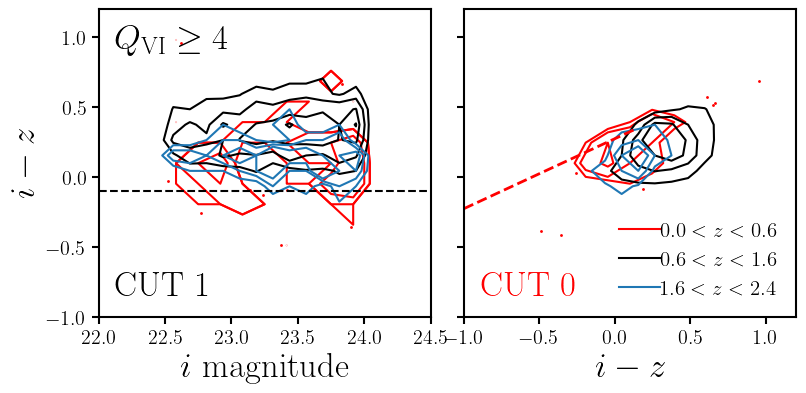

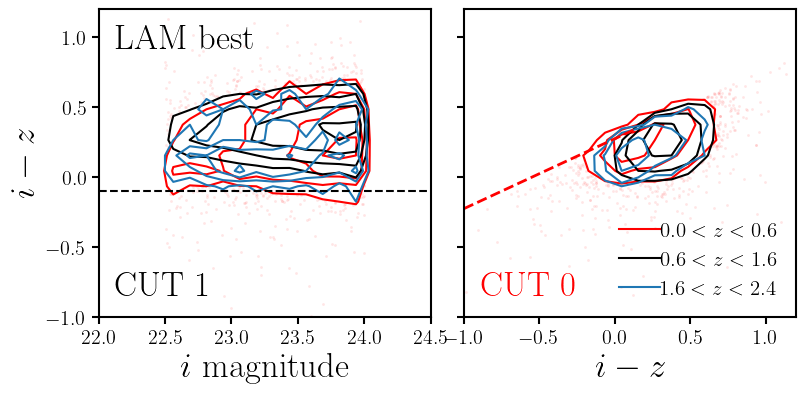

In [79]:
fig = plt.figure(figsize=(9, 4))
for _ii, i, j in zip([0, 1], [2, 3], [1, 2]): 
    sub = fig.add_subplot(1, 2, _ii+1)

    for _i in range(3): 
        _zlim = ((kota['z_measured'] > [0, 0.6, 1.6][_i]) & (kota['z_measured'] < [0.6, 1.6, 2.4][_i]) &
                    (0.5*(kota['user1'] + kota['user2']) >= 4) & cut0[i_match_kota])
        if _i == 0: 
            sub.scatter(_arrs[j][i_match_kota][_zlim], 
                _arrs[i][i_match_kota][_zlim], c='r', s=1)
            _ = DFM.hist2d(
                _arrs[j][i_match_kota][_zlim], 
                _arrs[i][i_match_kota][_zlim],
                color=['r', 'k', 'C0'][_i],
                range=[_ranges[j], _ranges[i]], bins=15, 
                plot_density=False, plot_datapoints=True, smooth=False, ax=sub)
        else: 
            _ = DFM.hist2d(
                _arrs[j][i_match_kota][_zlim], 
                _arrs[i][i_match_kota][_zlim],
                color=['r', 'k', 'C0'][_i],
                range=[_ranges[j], _ranges[i]], bins=20, 
                plot_density=False, plot_datapoints=False, smooth=False, ax=sub)            
    sub.set_xlabel(_lbls[j], fontsize=25)
    sub.set_xlim(_ranges[j])
    sub.set_ylabel(_lbls[i], fontsize=25)
    sub.set_ylim(_ranges[i])
    

    if j == 2 and i == 3: 
        sub.plot([-1., 0.15], [-0.225, 0.35], c='r', lw=2, ls='--')
        sub.text(0.05, 0.05, r'CUT 0', color='r', ha='left', va='bottom', transform=sub.transAxes, fontsize=25)

    if i == 2: 
        sub.axhline(-0.1, color='k', linestyle='--')
        sub.text(0.05, 0.05, r'CUT 1', color='k', ha='left', va='bottom', transform=sub.transAxes, fontsize=25)

            
    if _ii > 0: 
        sub.set_yticklabels([])
        sub.set_ylabel('')
    else: 
        sub.text(0.05, 0.95, r'$Q_{\rm VI} \ge 4$', ha='left', va='top', transform=sub.transAxes, fontsize=25)
        
for _i in range(3): 
    sub.plot([], [], c=['r', 'k', 'C0'][_i],
                     label=r'$%.1f < z < %.1f$' % ([0, 0.6, 1.6][_i], [0.6, 1.6, 2.4][_i]))
sub.legend(loc='lower right', handletextpad=0., fontsize=15)

fig.subplots_adjust(wspace=0.1, hspace=0.1)
plt.show()

fig = plt.figure(figsize=(9, 4))
for _ii, i, j in zip([0, 1], [2, 3], [1, 2]): 
    sub = fig.add_subplot(1, 2, _ii+1)

    for _i in range(3): 
        _zlim = (lam1d_s25a['redshift'] > [0., 0.6, 1.6][_i]) & (lam1d_s25a['redshift'] < [0.6, 1.6, 2.4][_i]) & best_lam & cut0
        if _i == 0: 
            _ = DFM.hist2d(
                _arrs[j][_zlim], 
                _arrs[i][_zlim],
                color=['r', 'k', 'C0'][_i],
                range=[_ranges[j], _ranges[i]], bins=20, 
                plot_density=False, plot_datapoints=True, smooth=False, ax=sub)
        else: 
            _ = DFM.hist2d(
                _arrs[j][_zlim], 
                _arrs[i][_zlim],
                color=['r', 'k', 'C0'][_i],
                range=[_ranges[j], _ranges[i]], bins=20, 
                plot_density=False, plot_datapoints=False, smooth=False, ax=sub)
    sub.set_xlabel(_lbls[j], fontsize=25)
    sub.set_xlim(_ranges[j])
    sub.set_ylabel(_lbls[i], fontsize=25)
    sub.set_ylim(_ranges[i])
    

    if j == 2 and i == 3: 
        sub.plot([-1., 0.15], [-0.225, 0.35], c='r', lw=2, ls='--')
        sub.text(0.05, 0.05, r'CUT 0', color='r', ha='left', va='bottom', transform=sub.transAxes, fontsize=25)

    if i == 2: 
        sub.axhline(-0.1, color='k', linestyle='--')
        sub.text(0.05, 0.05, r'CUT 1', color='k', ha='left', va='bottom', transform=sub.transAxes, fontsize=25)
        
    
    if _ii > 0: 
        sub.set_yticklabels([])
        sub.set_ylabel('')
    else: 
        sub.text(0.05, 0.95, r'LAM best', ha='left', va='top', transform=sub.transAxes, fontsize=25)

for _i in range(3): 
    sub.plot([], [], c=['r', 'k', 'C0'][_i],
                     label=r'$%.1f < z < %.1f$' % ([0, 0.6, 1.6][_i], [0.6, 1.6, 2.4][_i]))
sub.legend(loc='lower right', handletextpad=0., fontsize=15)

fig.subplots_adjust(wspace=0.1, hspace=0.1)

In [74]:
cut1 = (i_mag - z_mag) > -0.1

In [82]:
for i in range(3): 
    print(['z < 0.6', '0.6 < z < 1.6', '1.6 < z < 2.4'][i])
    zlim = ((kota['z_measured'] > [0, 0.6, 1.6][i]) & (kota['z_measured'] < [0.6, 1.6, 2.4][i]) &
                    (0.5*(kota['user1'] + kota['user2']) >= 4))    
    print('CUT 0: (i-z) - (g-r)', 1.-np.sum(zlim & cut0[i_match_kota])/np.sum(zlim))
    print('CUT 1: (i-z)', 1.-np.sum(zlim & cut1[i_match_kota])/np.sum(zlim))
    print('CUT 0 + 1:', 1.-np.sum(zlim & cut0[i_match_kota] & cut1[i_match_kota])/np.sum(zlim))
    print()

z < 0.6
CUT 0: (i-z) - (g-r) 0.33333333333333337
CUT 1: (i-z) 0.3448275862068966
CUT 0 + 1: 0.4367816091954023

0.6 < z < 1.6
CUT 0: (i-z) - (g-r) 0.018973695558430315
CUT 1: (i-z) 0.014230271668822736
CUT 0 + 1: 0.023717119448037893

1.6 < z < 2.4
CUT 0: (i-z) - (g-r) 0.017857142857142905
CUT 1: (i-z) 0.0625
CUT 0 + 1: 0.0714285714285714



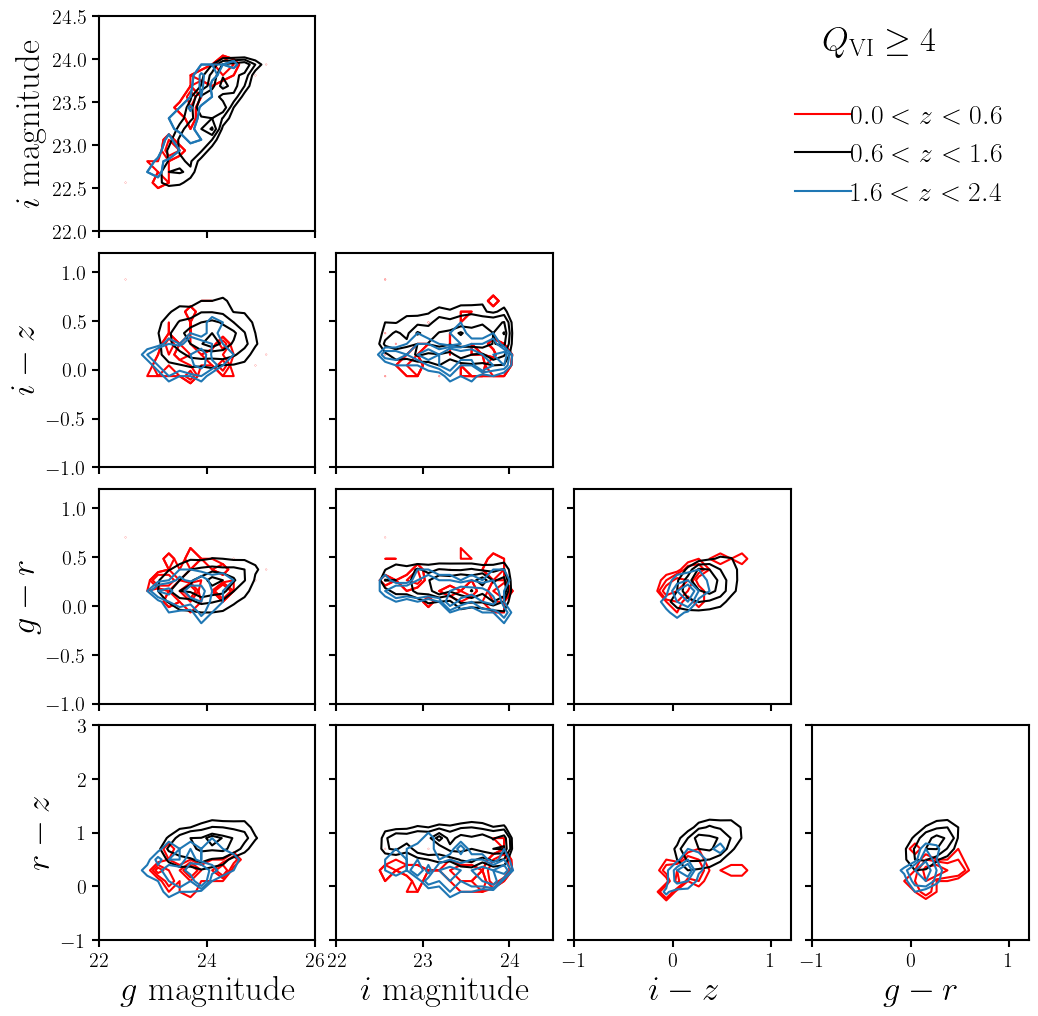

In [85]:
fig = plt.figure(figsize=(12, 12))
for i in range(5): 
    for j in range(5): 
        if j >= i: continue
        sub = fig.add_subplot(4,4,4*(i-1)+j+1)

        for _i in range(3): 
            _zlim = ((kota['z_measured'] > [0, 0.6, 1.6][_i]) & (kota['z_measured'] < [0.6, 1.6, 2.4][_i]) &
                    (0.5*(kota['user1'] + kota['user2']) >= 4) & cut0[i_match_kota] & cut1[i_match_kota])
            
            _ = DFM.hist2d(
                _arrs[j][i_match_kota][_zlim], 
                _arrs[i][i_match_kota][_zlim],
                color=['r', 'k', 'C0'][_i],
                range=[_ranges[j], _ranges[i]], bins=20, 
                plot_density=False, plot_datapoints=False, smooth=False, ax=sub)
        sub.set_xlabel(_lbls[j], fontsize=25)
        sub.set_xlim(_ranges[j])
        sub.set_ylabel(_lbls[i], fontsize=25)
        sub.set_ylim(_ranges[i])
        if j == 0 and i < 4: sub.set_xticklabels([])
        
        if i < 4: 
            sub.set_xlabel('')
            sub.set_xticklabels([])
        if j > 0: 
            sub.set_yticklabels([])
            sub.set_ylabel('')

sub = fig.add_subplot(4,4,4)
for _i in range(3): 
    sub.plot([], [], c=['r', 'k', 'C0'][_i],
                     label=r'$%.1f < z < %.1f$' % ([0, 0.6, 1.6][_i], [0.6, 1.6, 2.4][_i]))
sub.text(0.05, 0.95, r'$Q_{\rm VI} \ge 4$', ha='left', va='top', transform=sub.transAxes, fontsize=25)
sub.legend(loc='lower right', handletextpad=0., fontsize=20)
sub.axis('off')


fig.subplots_adjust(wspace=0.1, hspace=0.1)

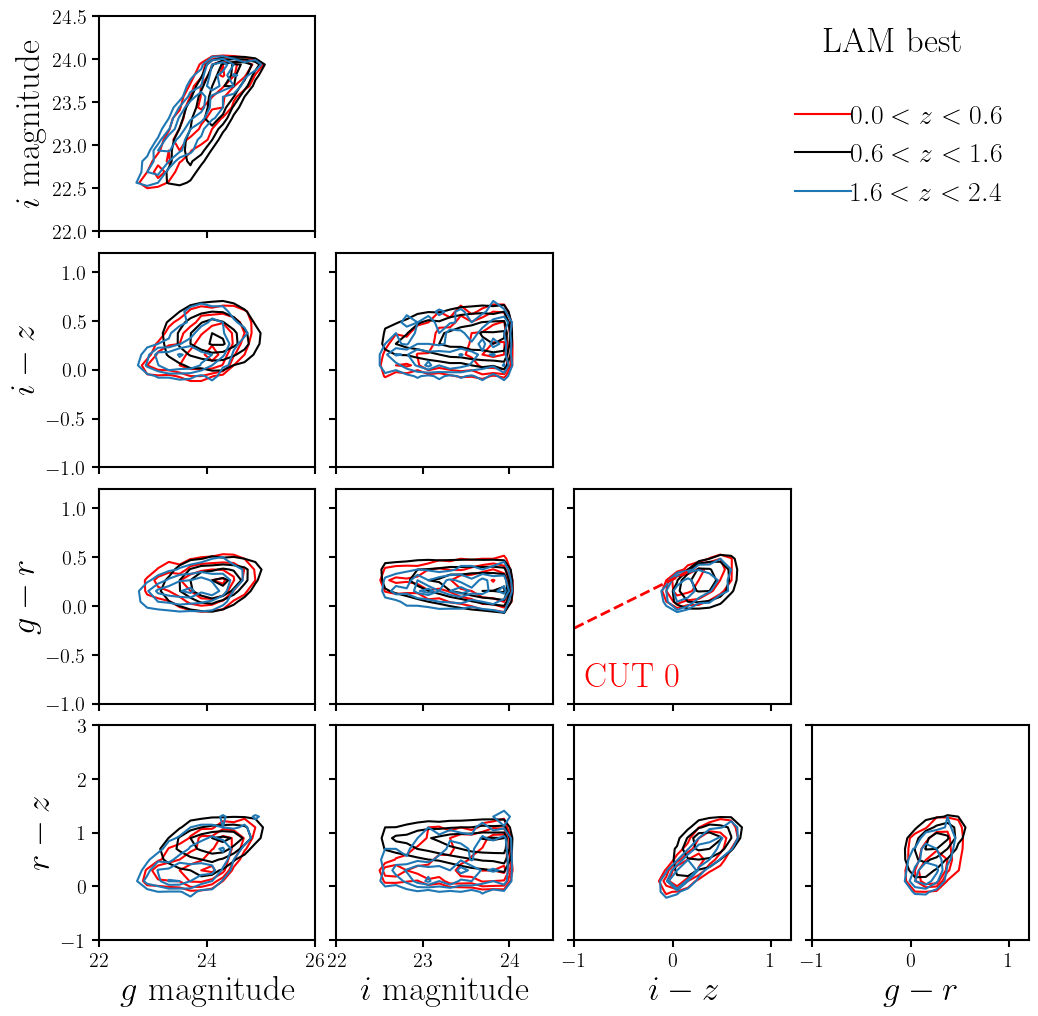

In [83]:
fig = plt.figure(figsize=(12, 12))
for i in range(5): 
    for j in range(5): 
        if j >= i: continue
        sub = fig.add_subplot(4,4,4*(i-1)+j+1)

        for _i in range(3): 
            _zlim = (lam1d_s25a['redshift'] > [0., 0.6, 1.6][_i]) & (lam1d_s25a['redshift'] < [0.6, 1.6, 2.4][_i]) & best_lam & cut0 & cut1
            _ = DFM.hist2d(
                _arrs[j][_zlim], 
                _arrs[i][_zlim],
                color=['r', 'k', 'C0'][_i],
                range=[_ranges[j], _ranges[i]], bins=20, 
                plot_density=False, plot_datapoints=False, smooth=False, ax=sub)
        sub.set_xlabel(_lbls[j], fontsize=25)
        sub.set_xlim(_ranges[j])
        sub.set_ylabel(_lbls[i], fontsize=25)
        sub.set_ylim(_ranges[i])
        

        if j == 2 and i == 3: 
            sub.plot([-1., 0.15], [-0.225, 0.35], c='r', lw=2, ls='--')
            sub.text(0.05, 0.05, r'CUT 0', color='r', ha='left', va='bottom', transform=sub.transAxes, fontsize=25)
            
        if j == 0 and i < 4: 
            sub.set_xticklabels([])
        
        if i < 4: 
            sub.set_xlabel('')
            sub.set_xticklabels([])
        if j > 0: 
            sub.set_yticklabels([])
            sub.set_ylabel('')

sub = fig.add_subplot(4,4,4)
for _i in range(3): 
    sub.plot([], [], c=['r', 'k', 'C0'][_i],
                     label=r'$%.1f < z < %.1f$' % ([0, 0.6, 1.6][_i], [0.6, 1.6, 2.4][_i]))
sub.text(0.05, 0.95, r'LAM best', ha='left', va='top', transform=sub.transAxes, fontsize=25)
sub.legend(loc='lower right', handletextpad=0., fontsize=20)
sub.axis('off')


fig.subplots_adjust(wspace=0.1, hspace=0.1)